In [ ]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import importlib ## required to reload updated modules
importlib.reload(hlp)
importlib.reload(prep)

<module 'preparations' from '/content/preparations.py'>

In [ ]:
# Libraries
import os # to interact with the operating system (file paths, folders, etc.)
import pandas as pd  # for handling tabular data
import numpy as np # for numerical computations

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D # flattens CNN output before passing to Dense layers
from tensorflow.keras.layers import Dropout # dropout for regularization

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping # stop training early if no improvement
from tensorflow.keras.callbacks import ReduceLROnPlateau # reduce learning rate if validation performance stagnates

# Reporting
from sklearn.metrics import classification_report  # standard classification metrics
from sklearn.metrics import confusion_matrix # confusion matrix
from imblearn.metrics import classification_report_imbalanced # better suited for imbalanced datasets

# Imports for visualizations
import matplotlib.pyplot as plt # basic plotting
import seaborn as sns # advanced statistical visualization
%matplotlib inline

In [3]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Transfer Learning

##### Dataset loading and preprocessing

In [5]:
# Load the original dataset, if not done yet
prep.download_and_move_dataset()

Dataset already exists.


In [ ]:
# Read in the images and labels using a helper function
# Also returns class_names in the order of label encoding
train_ds, val_ds, class_names = hlp.read_only_xray_images()

#Dataset info from the output:
# 21165 images in total
# 16932 used for training, 4233 for validation
# 4 classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

Created empty directory: /tmp_261224613
Made directory: /tmp_261224613/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_261224613/Lung_Opacity/masks
Made directory: /tmp_261224613/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_261224613/COVID/masks
Made directory: /tmp_261224613/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_261224613/Viral Pneumonia/masks
Made directory: /tmp_261224613/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_261224613/Normal/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 224, 224, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 224, 224, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_261224613/Lun

In [ ]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print('Batch shape:', images.shape, labels.shape)
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

#Each batch contains 32 images, so:
# 530 batches for training
# 133 batches for validation

Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 224, 224, 3) (32,)
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 3
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 3
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0


In [ ]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1 #Accumulates the count of each class across the training dataset.

# Convert label indices to class names
# Map label indices back to class names for readability
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

# Compute class weights:
# Formula: total_samples / (num_classes * samples_per_class)
class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label]) #helps the model pay more attention to underrepresented classes (like "Viral Pneumonia").
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)
#This dictionary is passed to the model during .fit(...) to balance the learning.


Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


In [ ]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
# Preprocessing for VGG16: apply the correct normalization for pretrained networks
from tensorflow.keras.applications.vgg16 import preprocess_input

## Apply preprocessing function to each image in the datasets
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

#### Try with VGG16 (imagenet pretrained)

In [ ]:
# Make sure, the models folder exists
if not os.path.exists(os.path.join('..', 'models')):
    os.makedirs(os.path.join('..', 'models'))

# This model name for saving and loading
model_name = os.path.join('..', 'models', '3c_vgg16_dense128.keras')

In [ ]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16 ## Import VGG16 architecture from Keras Applications

# VGG16 model
# Load the pretrained VGG16 model without the top classification layer
# We use weights pretrained on ImageNet and remove the top Dense layers
base_model = VGG16(weights='imagenet', include_top=False)
#include_top=False: excludes the final Dense layers from ImageNet classification
#This makes it possible to attach custom classification layers for our 4-class X-ray problem

# Freeze the layers of VGG16
base_model.trainable = False

# Model creation using the Functional API
# Create the input layer with shape matching the image size (224x224 RGB)
inputs = Input(shape=(224, 224, 3))

# Build the model
x = base_model(inputs) # Pass input through VGG16 base model
x = GlobalAveragePooling2D()(x) # Apply global average pooling to convert 3D feature maps to 1D vector
x = Dense(1024, activation='relu')(x) # Add a fully connected layer with 1024 neurons and ReLU activation
x = Dropout(rate=0.2)(x)
x = Dense(128, activation='relu')(x) # Second dense layer with 128 neurons instead of 512 (testing a smaller size)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x) # Output layer with softmax for multi-class classification

vgg16 = Model(inputs=inputs, outputs=outputs) # Create the full model using Keras Functional API

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Applied Callbacks
# Define EarlyStopping to stop training if val_loss doesn't improve
early_stopping = EarlyStopping(
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 5 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min', # lower is better
                                monitor='val_loss') # monitor validation loss

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01, # consider stagnation if less than 1% change
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [ ]:
# Compile the model with optimizer, loss function, and evaluation metric
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
# Adam optimizer for adaptive learning rate
# Suitable for integer-encoded multiclass labels
# Track accuracy during training and evaluation

# Print how it looks like
vgg16.summary() # Show a summary of the model architecture
 
# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = hlp.model_summary_to_df(vgg16)
display(df_summary)

#Key point: Only the last few layers (Dense + Dropout) are trainable – the base VGG16 weights remain fixed.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │         525,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,371,716 (58.64 MB)

 Trainable params: 657,028 (2.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1 (InputLayer),"(None, 224, 224, 3)",0
1,vgg16 (Functional),"(None, 7, 7, 512)","14,714,688"
2,global_average_pooling2d,"(None, 512)",0
3,(GlobalAveragePooling2D),,
4,dense (Dense),"(None, 1024)","525,312"
5,dropout (Dropout),"(None, 1024)",0
6,dense_1 (Dense),"(None, 128)","131,200"
7,dropout_1 (Dropout),"(None, 128)",0
8,dense_2 (Dense),"(None, 4)",516


In [ ]:
# Train it with the entire dataset (takes very long!)
history_model = vgg16.fit(train_ds,  # training dataset
                          epochs=25, # max number of training epochs
                          validation_data=val_ds, # validation dataset
                          class_weight=class_weights_dict, # handle imbalanced classes
                          callbacks=[early_stopping, reduce_learning_rate]) # training control callbacks

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 43ms/step - accuracy: 0.6882 - loss: 0.9179 - val_accuracy: 0.8495 - val_loss: 0.3938 - learning_rate: 0.0010
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8401 - loss: 0.3415 - val_accuracy: 0.8868 - val_loss: 0.3107 - learning_rate: 0.0010
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8639 - loss: 0.2932 - val_accuracy: 0.8949 - val_loss: 0.2772 - learning_rate: 0.0010
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8782 - loss: 0.2575 - val_accuracy: 0.8935 - val_loss: 0.2935 - learning_rate: 0.0010
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8805 - loss: 0.2661 - val_accuracy: 0.8925 - val_loss: 0.3003 - learning_rate: 0.0010
Epoch 6/25
529/530 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8978 - loss: 0.2085
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
530/530 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.8978 - lo

In [15]:
# Save the model for potential later use
vgg16.save(model_name)

##### Evalution

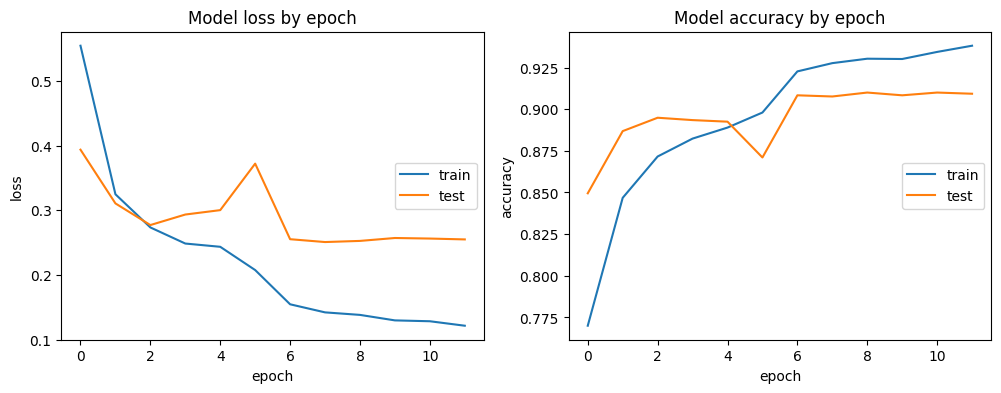

In [ ]:
hlp.plot_learning_curve(history_model)
# Plot training and validation loss & accuracy curves

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.
### The accuracy in the graph clearly reaches around 91%, not 70% anymore

In [17]:
from tensorflow import keras
vgg16 = keras.models.load_model(model_name)

In [18]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = hlp.get_predictions_and_labels(vgg16, val_ds)

,pre,rec,spe,f1,geo,iba,sup
COVID,0.923928,0.936886,0.984375,0.930362,0.960337,0.917868,713.000000
Lung_Opacity,0.857261,0.886695,0.943937,0.871730,0.914869,0.832194,1165.000000
Normal,0.931103,0.906220,0.936552,0.918493,0.921261,0.846147,2058.000000
Viral Pneumonia,0.937086,0.952862,0.995173,0.944908,0.973788,0.944250,297.000000
avg_pre,0.909992,0.909992,0.909992,0.909992,0.909992,0.909992,0.909992
avg_rec,0.909284,0.909284,0.909284,0.909284,0.909284,0.909284,0.909284
avg_spe,0.950753,0.950753,0.950753,0.950753,0.950753,0.950753,0.950753
avg_f1,0.909476,0.909476,0.909476,0.909476,0.909476,0.909476,0.909476
avg_geo,0.929769,0.929769,0.929769,0.929769,0.929769,0.929769,0.929769
avg_iba,0.861271,0.861271,0.861271,0.861271,0.861271,0.861271,0.861271


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,668,21,22,2
Lung_Opacity,28,1033,104,0
Normal,25,151,1865,17
Viral Pneumonia,2,0,12,283


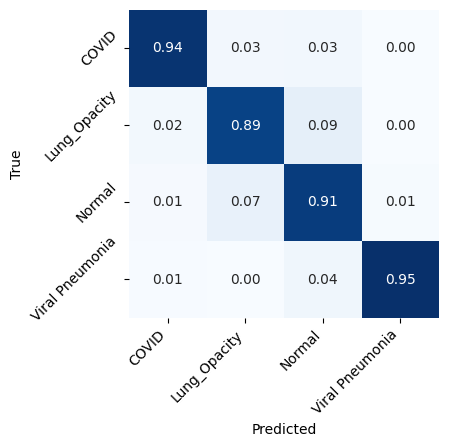

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              668            21      22                2
 Lung_Opacity        28          1033     104                0
 Normal              25           151    1865               17
 Viral Pneumonia      2             0      12              283,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.923928     0.936886     0.984375     0.930362   
 Lung_Opacity        0.857261     0.886695     0.943937     0.871730   
 Normal              0.931103     0.906220     0.936552     0.918493   
 Viral Pneumonia     0.937086     0.952862     0.995173     0.944908   
 avg_pre             0.909992     0.909992     0.909992     0.909992   
 avg_rec             0.909284     0.909284     0.909284     0.909284   
 avg_spe             0.950753     0.950753     0.950753     0.950753   
 avg_f1              0.909476     0.909476     0.909476     0.909476   

In [ ]:
hlp.report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes really well
# Conclusion: The model classifies all four classes with high precision and recall.
# Minor confusion exists between 'Normal' and 'Lung_Opacity', but overall performance is strong.